# Analyze Dumped Model Inputs

这个 notebook 用来分析 `train_light.py` 训练时导出的模型输入 dump。

默认读取 `weights_japan_overfit/model_input_dumps`，可按需要修改 `DUMP_ROOT`。

In [3]:
from pathlib import Path
import json
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DUMP_ROOT = Path('../model_input_dumps')
assert DUMP_ROOT.exists(), f'Dump dir not found: {DUMP_ROOT.resolve()}'

manifest_path = DUMP_ROOT / 'manifest.json'
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
manifest

{'epochs': [1, 2, 3], 'include_val': True, 'max_batches_per_epoch': None}

In [4]:
def list_epochs(split='train'):
    split_dir = DUMP_ROOT / split
    if not split_dir.exists():
        return []
    return sorted([p.name for p in split_dir.iterdir() if p.is_dir()])

def list_batches(split='train', epoch='epoch_001'):
    epoch_dir = DUMP_ROOT / split / epoch
    if not epoch_dir.exists():
        return []
    return sorted([p.name for p in epoch_dir.glob('batch_*.pt')])

def load_batch(split='train', epoch='epoch_001', batch='batch_0000.pt'):
    path = DUMP_ROOT / split / epoch / batch
    return torch.load(path, map_location='cpu')

print('train epochs:', list_epochs('train'))
print('val epochs:', list_epochs('val'))

train epochs: ['epoch_001', 'epoch_002', 'epoch_003']
val epochs: ['epoch_001', 'epoch_002', 'epoch_003']


In [5]:
batch = load_batch('train', list_epochs('train')[0], list_batches('train', list_epochs('train')[0])[0])
print(batch.keys())
print('epoch:', batch['epoch'], 'split:', batch['split'], 'batch_idx:', batch['batch_idx'])
print('input tensor shapes:')
for i, x in enumerate(batch['inputs']):
    if torch.is_tensor(x):
        print(f'  inputs[{i}] ->', tuple(x.shape), x.dtype)
    else:
        print(f'  inputs[{i}] ->', type(x))
print('label tensor shapes:')
for i, x in enumerate(batch['labels']):
    print(f'  labels[{i}] ->', tuple(x.shape), x.dtype)
print('p_pick_info keys:', sorted(batch['p_pick_info'].keys()))

dict_keys(['epoch', 'split', 'batch_idx', 'global_step', 'inputs', 'labels', 'p_pick_info'])
epoch: 1 split: train batch_idx: 0
input tensor shapes:
  inputs[0] -> (4, 25, 3, 10000) torch.float32
  inputs[1] -> (4, 25, 3) torch.float32
  inputs[2] -> (4, 25) torch.bool
  inputs[3] -> (4, 15, 3) torch.float32
  inputs[4] -> (4, 15) torch.bool
label tensor shapes:
  labels[0] -> (4, 1) torch.float32
  labels[1] -> (4, 3) torch.float32
  labels[2] -> (4, 15, 1) torch.float32
p_pick_info keys: ['debug_raw_full_p_picks', 'debug_raw_metadata', 'debug_raw_pga', 'debug_raw_pga_valid', 'debug_raw_station_valid', 'debug_raw_waveforms', 'event_id', 'loc_center', 'loc_target_abs', 'loc_target_mode', 'raw', 'selected_input_indices', 'shift', 'shifted']


In [6]:
def summarize_batch(batch):
    wave = batch['inputs'][0]             # (B, S, C, T)
    metadata = batch['inputs'][1]         # (B, S, D)
    station_valid = batch['inputs'][2]    # (B, S)
    p_pick_info = batch['p_pick_info']
    print('wave mean/std:', float(wave.mean()), float(wave.std()))
    print('metadata abs mean/max:', float(metadata.abs().mean()), float(metadata.abs().max()))
    print('valid stations per sample:', station_valid.sum(dim=1).tolist())
    if 'event_id' in p_pick_info:
        print('event_id:', p_pick_info['event_id'])
    if 'selected_input_indices' in p_pick_info:
        print('selected_input_indices[0]:', p_pick_info['selected_input_indices'][0].tolist())
    if len(batch['labels']) >= 3:
        pga = batch['labels'][-1]
        print('pga label mean/std:', float(pga.mean()), float(pga.std()))

summarize_batch(batch)

wave mean/std: 2.827748858180712e-06 9.802253771340474e-05
metadata abs mean/max: 0.8952370285987854 3.5845999717712402
valid stations per sample: [5, 25, 25, 25]
event_id: ['20240101185000', '20240207162500', '20240531015800', '20240625173100']
selected_input_indices[0]: [0, 1, 2, 3, 4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
pga label mean/std: -1.423784613609314 0.81564861536026


In [8]:
def plot_waveforms(batch, sample_idx=0, station_idx=0, channels=(0, 1, 2), show_raw=True):
    inputs = batch['inputs']
    pinfo = batch['p_pick_info']
    wave = inputs[0][sample_idx, station_idx].numpy()  # (C, T)
    shifted_p = float(pinfo['shifted'][sample_idx, station_idx])
    raw_p = float(pinfo['raw'][sample_idx, station_idx])
    ncols = 2 if show_raw and 'debug_raw_waveforms' in pinfo else 1
    fig, axes = plt.subplots(len(channels), ncols, figsize=(6 * ncols, 2.5 * len(channels)), squeeze=False)
    for r, ch in enumerate(channels):
        ax = axes[r, 0]
        ax.plot(wave[ch], lw=1)
        ax.axvline(shifted_p, color='tab:red', ls='--', label='shifted p_pick')
        ax.set_title(f'model input | sample={sample_idx} station={station_idx} ch={ch}')
        ax.legend(loc='upper right')
        if ncols == 2:
            raw_wave = pinfo['debug_raw_waveforms'][sample_idx, station_idx].numpy()
            ax2 = axes[r, 1]
            ax2.plot(raw_wave[ch], lw=1)
            ax2.axvline(raw_p, color='tab:orange', ls='--', label='raw p_pick')
            ax2.set_title(f'preprocess snapshot | sample={sample_idx} station={station_idx} ch={ch}')
            ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close('all')


In [37]:
def plot_coords(batch, sample_idx=0):
    inputs = batch['inputs']
    pinfo = batch['p_pick_info']
    coords = inputs[1][sample_idx].numpy()
    valid = inputs[2][sample_idx].numpy().astype(bool)
    fig, axes = plt.subplots(1, 2 if 'debug_raw_metadata' in pinfo else 1, figsize=(12, 5))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes[0].scatter(coords[valid, 1], coords[valid, 0], c='tab:blue', label='model coords')
    axes[0].set_title('Model input coords')
    axes[0].set_xlabel('coord[1]')
    axes[0].set_ylabel('coord[0]')
    axes[0].legend()
    print(coords[valid])
    if 'debug_raw_metadata' in pinfo:
        raw_coords = pinfo['debug_raw_metadata'][sample_idx].numpy()
        raw_valid = pinfo['debug_raw_station_valid'][sample_idx].numpy().astype(bool)
        axes[1].scatter(raw_coords[raw_valid, 1], raw_coords[raw_valid, 0], c='tab:green', label='raw coords')
        print(raw_coords[raw_valid])
        axes[1].set_title('Preprocess snapshot coords')
        axes[1].set_xlabel('lon / coord[1]')
        axes[1].set_ylabel('lat / coord[0]')
        axes[1].legend()
    plt.tight_layout()
    plt.show()
    plt.close('all')


In [12]:
def plot_pick_and_pga_distributions(batch, sample_idx=0):
    pinfo = batch['p_pick_info']
    shifted = pinfo['shifted'][sample_idx].numpy()
    raw = pinfo['raw'][sample_idx].numpy()
    valid_shifted = shifted[shifted > 0]
    valid_raw = raw[raw > 0]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if len(valid_raw) > 0:
        axes[0].hist(valid_raw, bins=20, color='tab:orange', alpha=0.8)
    axes[0].set_title('Raw p_pick distribution')
    if len(valid_shifted) > 0:
        axes[1].hist(valid_shifted, bins=20, color='tab:red', alpha=0.8)
    axes[1].set_title('Shifted p_pick distribution')
    if len(batch['labels']) >= 3:
        pga = batch['labels'][-1][sample_idx, :, 0].numpy()
        axes[2].hist(pga, bins=20, color='tab:blue', alpha=0.8)
        axes[2].set_title('PGA label distribution')
    plt.tight_layout()
    plt.show()
    plt.close('all')


In [49]:
sample_idx=1
station_idx=24

In [50]:
batch["inputs"][2][sample_idx].numpy().astype(bool)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [55]:
batch['p_pick_info']['selected_input_indices']

tensor([[  0,   1,   2,   3,   4,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
          -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],
        [101,  85,  84,   4,  53,  44,  22,  86,  97,  25,   9,  36,   3,  50,
          38,  28,  15,  61,  54,  80,  40,  70,  94,  99,  32],
        [ 24,  88,  72,  21,  91,  31,  62,   3,  71,  50,  57,   6,  15,  12,
          23,  87,  38,  67, 104,  75,  48,  74,  18,  80,  32],
        [ 54,  31,  87,  37,  11,  52, 101, 110,  58,  22,  75, 120, 136,  59,
           5,  90,  19,  92,  97, 132,  99,  71,  13,  66,  40]])

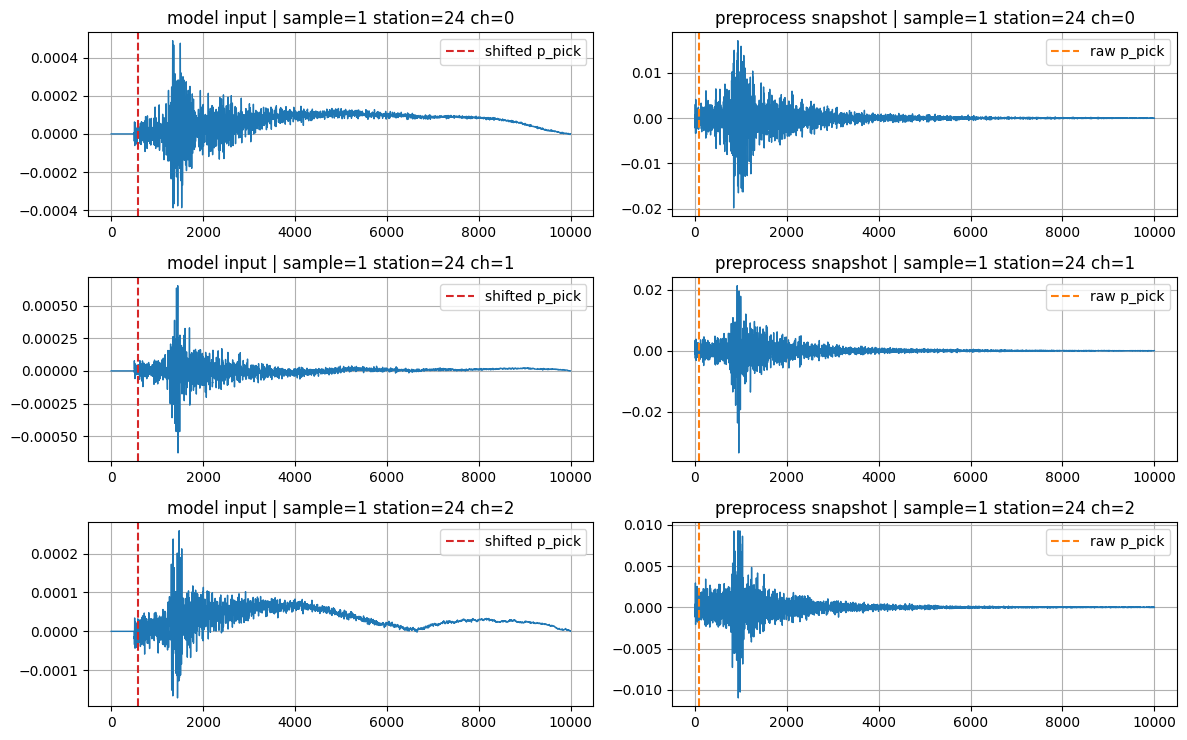

In [51]:
plot_waveforms(batch, sample_idx=sample_idx, station_idx=station_idx)

[[ 1.3400e+00  9.5510e-01 -9.8600e-01]
 [ 1.9207e+00  1.6377e+00 -3.7000e-02]
 [ 2.0307e+00  1.5320e+00  8.0000e-02]
 [ 2.6478e+00  1.9465e+00  6.0000e-03]
 [ 3.0861e+00  1.7120e+00  1.4000e-01]
 [ 3.4492e+00  1.3374e+00  6.5000e-02]
 [ 1.7261e+00  1.5110e+00  6.5000e-02]
 [ 1.9207e+00  1.6377e+00  8.0000e-02]
 [ 1.5158e+00  1.3421e+00 -2.0210e-01]
 [ 1.5660e+00  9.7670e-01  1.7000e-02]
 [ 2.1453e+00  1.1527e+00  4.3000e-02]
 [ 2.5450e+00  3.4810e-01  2.0000e-02]
 [ 2.7356e+00  1.9671e+00  9.0000e-03]
 [ 2.1809e+00  1.3909e+00  6.2000e-01]
 [ 2.3548e+00  3.8690e-01  6.5000e-02]
 [ 1.1037e+00  8.7080e-01  3.0000e-03]
 [ 2.6954e+00  1.1477e+00  1.2000e-01]
 [ 2.7435e+00  1.9087e+00  1.0000e-01]
 [ 3.0861e+00  1.7120e+00  2.4000e-01]
 [ 2.2741e+00  1.8233e+00  4.4000e-02]
 [ 3.5846e+00  1.1547e+00  8.5000e-02]
 [ 2.4630e+00  1.6775e+00  5.5200e-01]
 [ 1.1133e+00  8.4410e-01  1.0000e-02]
 [ 1.6993e+00  1.4176e+00 -1.0000e-02]
 [ 2.1740e+00  7.1290e-01  2.8000e-01]]
[[ 3.834000e+01  1.40955

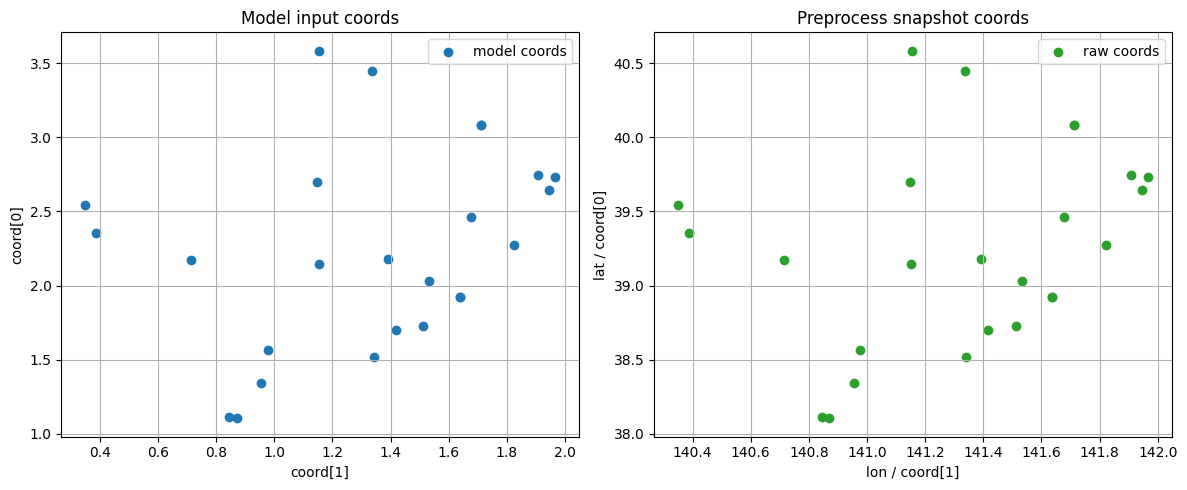

In [52]:
plot_coords(batch, sample_idx=sample_idx)

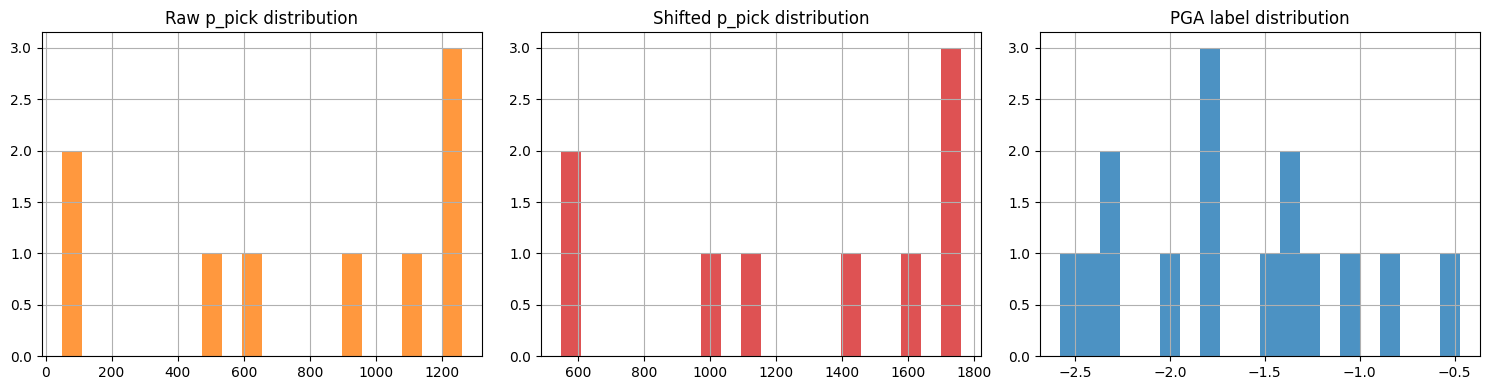

In [56]:
plot_pick_and_pga_distributions(batch, sample_idx=sample_idx)